In [1]:
from modeling.train import train
from modeling.predict import predict
from dataset import CSVDataModule
from plots import *

In [2]:
data_module = CSVDataModule()

In [3]:
trainer = train(data_module, "../models", "../logs")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\Mikelats\Desktop\Master\Software Development\Practice\SDOMLpractice-main\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\Mikelats\Desktop\Master\Software Development\Practice\SDOMLpractice-main\models exists and is not empty.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | l1      | Sequential       | 834    | train | 0    
1 | loss_fn | CrossEn

Epoch 19: 100%|██████████| 8/8 [00:00<00:00, 78.53it/s, v_num=7, train_loss_step=0.168, train_acc_step=0.962, train_loss_epoch=0.182, train_acc_epoch=0.930]  

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 8/8 [00:00<00:00, 68.68it/s, v_num=7, train_loss_step=0.168, train_acc_step=0.962, train_loss_epoch=0.182, train_acc_epoch=0.930]


In [4]:
y_true = data_module.train_ds.y
y_pred, y_prob = predict(trainer, data_module, "../models/last.ckpt")

C:\Users\Mikelats\Desktop\Master\Software Development\Practice\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Mikelats\Desktop\Master\Software Development\Practice\SDOMLpractice-main\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 8/8 [00:00<00:00, 444.51it/s]


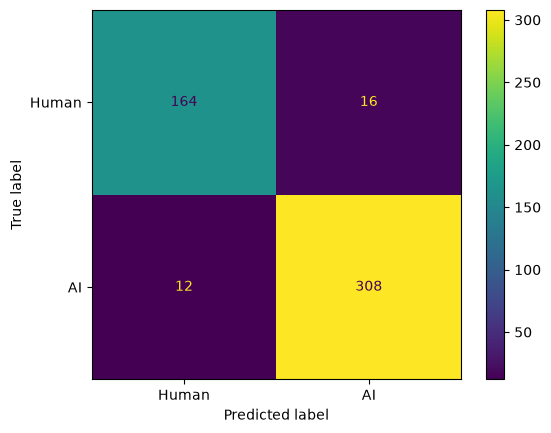

In [5]:
confusion_matrix(y_true, y_pred, "../reports/figures/ConfusionMatrix.png")

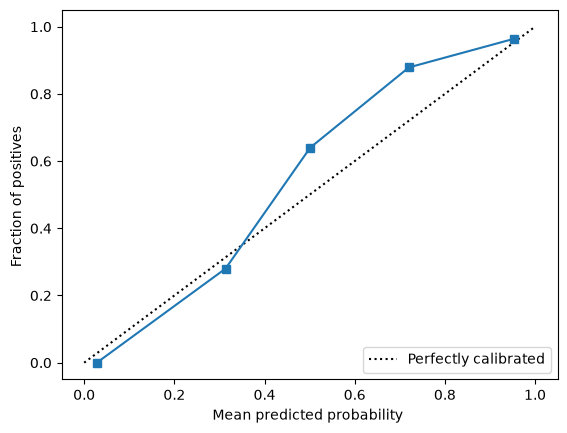

In [6]:
calibration_curve(y_true, y_prob, "../reports/figures/CalibrationCurve.png")

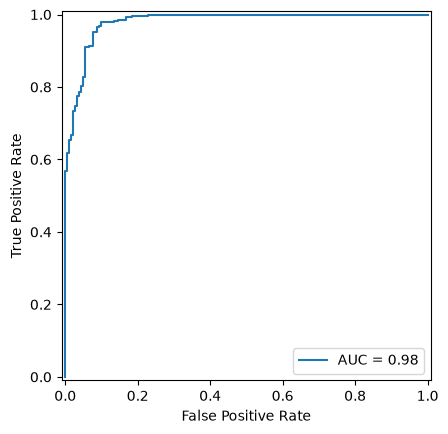

In [7]:
roc_curve(y_true, y_prob, "../reports/figures/ROCCurve.png")

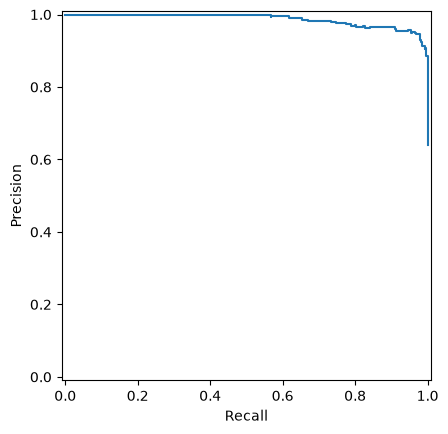

In [8]:
precision_recall_curve(y_true, y_prob, "../reports/figures/PrecisionRecall.png")

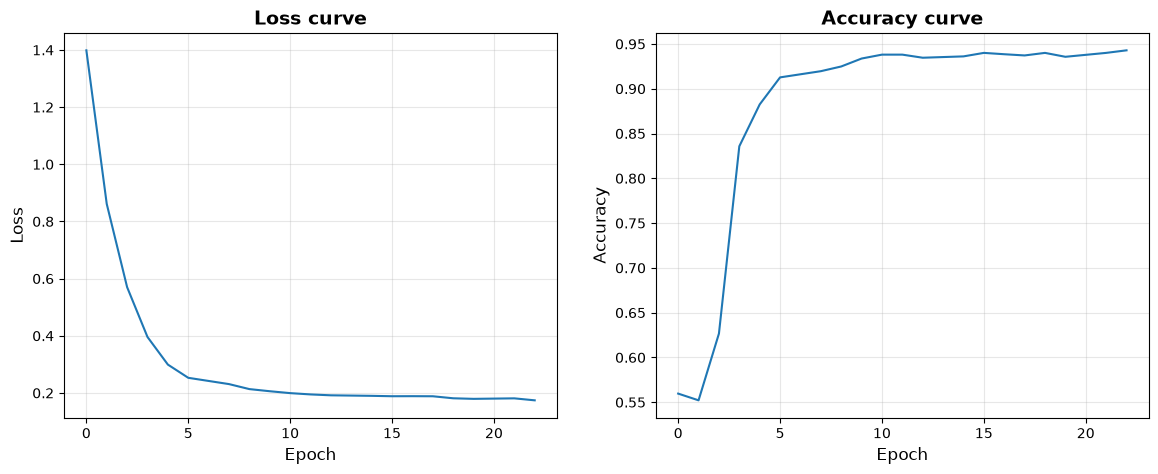

In [9]:
loss_accuracy_curves("../reports/figures/LossAccuracyCurves.png",
                     "../logs/train_log/version_0/metrics.csv"
                    )